# Clasificación Automática de Modulaciones (AMC)
## Comparación de arquitecturas: CNN, LSTM y TCN
Este notebook entrena y compara tres arquitecturas de redes neuronales sobre el dataset RadioML 2016.10a,
evaluando el trade-off entre accuracy y complejidad algorítmica.

## 1. Imports y configuración

In [18]:
import numpy as np
import polars as pl
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {DEVICE}')
N_CLASSES = 8
EPOCHS = 50
BATCH_SIZE = 256

Dispositivo: cpu


## 2. Carga y preparación del dataset

In [19]:
# Cargar dataset filtrado (generado en eda_radioml.py)
X = np.load('../rfml/radioml_X_digital.npy')           # (160000, 2, 128)
meta = pl.read_parquet('../rfml/radioml_metadata_digital.parquet')

mods = meta['mod'].to_numpy()
snrs = meta['snr'].to_numpy()

# Encodear etiquetas
le = LabelEncoder()
y = le.fit_transform(mods)

print(f'Clases ({len(le.classes_)}): {le.classes_}')
print(f'X shape: {X.shape}, y shape: {y.shape}')

Clases (8): ['8PSK' 'BPSK' 'CPFSK' 'GFSK' 'PAM4' 'QAM16' 'QAM64' 'QPSK']
X shape: (160000, 2, 128), y shape: (160000,)


In [20]:
# Mezclar antes del split (importante: el dataset viene ordenado por clase)
np.random.seed(42)
idx = np.random.permutation(len(X))
X = X[idx]
y = y[idx]
snrs = snrs[idx]

print('Primeras 10 etiquetas después de mezclar:', y[:10])
print('Clases:', [le.classes_[i] for i in y[:10]])

Primeras 10 etiquetas después de mezclar: [6 1 0 5 7 2 6 1 3 7]
Clases: ['QAM64', 'BPSK', '8PSK', 'QAM16', 'QPSK', 'CPFSK', 'QAM64', 'BPSK', 'GFSK', 'QPSK']


In [21]:
# Split 60 / 20 / 20
X_train, X_temp, y_train, y_temp, snr_train, snr_temp = train_test_split(
    X, y, snrs, test_size=0.4, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test, snr_val, snr_test = train_test_split(
    X_temp, y_temp, snr_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

def make_loader(X, y, batch_size=BATCH_SIZE, shuffle=True):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader   = make_loader(X_val,   y_val,   shuffle=False)
test_loader  = make_loader(X_test,  y_test,  shuffle=False)

Train: (96000, 2, 128) | Val: (32000, 2, 128) | Test: (32000, 2, 128)


## 3. Definición de arquitecturas

In [22]:
class CNNBaseline(nn.Module):
    def __init__(self, n_classes=8):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(2, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),   # agregado
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),   # agregado
            nn.ReLU(),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 128, 128),
            nn.BatchNorm1d(128),  # agregado
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

In [23]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_size=2, hidden_size=128, num_layers=2, n_classes=8):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.5
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.BatchNorm1d(64),   # agregado
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        out, _ = self.lstm(x)
        return self.classifier(out[:, -1, :])

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

In [24]:
class ResidualBlock(nn.Module):
    """Bloque residual con convolución dilatada — unidad básica de la TCN."""
    def __init__(self, channels, dilation):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size=3, padding=dilation, dilation=dilation),
            nn.BatchNorm1d(channels),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Conv1d(channels, channels, kernel_size=3, padding=dilation, dilation=dilation),
            nn.BatchNorm1d(channels),
            nn.ReLU(),
            nn.Dropout(0.2),
        )

    def forward(self, x):
        return x + self.conv(x)   # conexión residual


class TCN(nn.Module):
    """Temporal Convolutional Network para clasificación de modulaciones."""
    def __init__(self, n_classes=8, channels=64, dilations=[1, 2, 4, 8]):
        super().__init__()
        self.input_proj = nn.Conv1d(2, channels, kernel_size=1)
        self.blocks = nn.Sequential(
            *[ResidualBlock(channels, d) for d in dilations]
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(channels, n_classes)
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = self.blocks(x)
        return self.classifier(x)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

## 4. Loop de entrenamiento

In [25]:
def train_model(model, train_loader, val_loader, epochs=50, lr=1e-3, device='cpu'):
    model = model.to(device)
    optimizer = Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_weights = None

    for epoch in range(epochs):
        # Entrenamiento
        model.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        # Validación
        model.eval()
        val_losses, correct, total = [], 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                logits = model(X_batch)
                val_losses.append(criterion(logits, y_batch).item())
                correct += (logits.argmax(dim=1) == y_batch).sum().item()
                total += len(y_batch)

        train_loss = np.mean(train_losses)
        val_loss   = np.mean(val_losses)
        val_acc    = correct / total
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 10 == 0:
            print(f'Época {epoch+1:3d}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

    model.load_state_dict(best_weights)
    return model, history

## 5. Entrenamiento de modelos

In [26]:
print('=== CNN ===')
cnn = CNNBaseline(n_classes=N_CLASSES)
print(f'Parámetros: {cnn.count_parameters():,}')
cnn, cnn_history = train_model(cnn, train_loader, val_loader, epochs=EPOCHS, device=DEVICE)
torch.save(cnn.state_dict(), 'cnn.pt')

=== CNN ===
Parámetros: 1,063,048
Época  10/50 | Train Loss: 0.7842 | Val Loss: 7.0606 | Val Acc: 0.2495
Época  20/50 | Train Loss: 0.4737 | Val Loss: 3.4350 | Val Acc: 0.4106
Época  30/50 | Train Loss: 0.3477 | Val Loss: 3.5511 | Val Acc: 0.4704
Época  40/50 | Train Loss: 0.2807 | Val Loss: 10.9120 | Val Acc: 0.2831
Época  50/50 | Train Loss: 0.2376 | Val Loss: 4.8970 | Val Acc: 0.4222


In [27]:
print('=== LSTM ===')
lstm = LSTMClassifier(n_classes=N_CLASSES)
print(f'Parámetros: {lstm.count_parameters():,}')
lstm, lstm_history = train_model(lstm, train_loader, val_loader, epochs=EPOCHS, device=DEVICE)
torch.save(lstm.state_dict(), 'lstm.pt')

=== LSTM ===
Parámetros: 208,584
Época  10/50 | Train Loss: 2.0510 | Val Loss: 2.6132 | Val Acc: 0.1250
Época  20/50 | Train Loss: 2.0799 | Val Loss: 2.0795 | Val Acc: 0.1250
Época  30/50 | Train Loss: 2.0796 | Val Loss: 2.0794 | Val Acc: 0.1250
Época  40/50 | Train Loss: 2.0795 | Val Loss: 2.0794 | Val Acc: 0.1250
Época  50/50 | Train Loss: 2.0796 | Val Loss: 2.0795 | Val Acc: 0.1250


In [28]:
print('=== TCN ===')
tcn = TCN(n_classes=N_CLASSES)
print(f'Parámetros: {tcn.count_parameters():,}')
tcn, tcn_history = train_model(tcn, train_loader, val_loader, epochs=EPOCHS, device=DEVICE)
torch.save(tcn.state_dict(), 'tcn.pt')

=== TCN ===
Parámetros: 100,552
Época  10/50 | Train Loss: 0.8911 | Val Loss: 2.4259 | Val Acc: 0.3558
Época  20/50 | Train Loss: 0.8555 | Val Loss: 1.9341 | Val Acc: 0.3604
Época  30/50 | Train Loss: 0.8382 | Val Loss: 1.1434 | Val Acc: 0.5473
Época  40/50 | Train Loss: 0.8264 | Val Loss: 0.9505 | Val Acc: 0.6219
Época  50/50 | Train Loss: 0.8180 | Val Loss: 0.8972 | Val Acc: 0.6317


## 6. Evaluación

In [29]:
def evaluate_by_snr(model, X_test, y_test, snr_test, device='cpu'):
    model.eval()
    results = {}
    with torch.no_grad():
        for snr in sorted(np.unique(snr_test)):
            mask = snr_test == snr
            X_snr = torch.tensor(X_test[mask], dtype=torch.float32).to(device)
            y_snr = torch.tensor(y_test[mask], dtype=torch.long).to(device)
            preds = model(X_snr).argmax(dim=1)
            results[snr] = (preds == y_snr).float().mean().item()
    return results

def overall_accuracy(model, X_test, y_test, device='cpu', batch_size=512):
    model.eval()
    loader = make_loader(X_test, y_test, batch_size=batch_size, shuffle=False)
    correct, total = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch).argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += len(y_batch)
    return correct / total

cnn_snr  = evaluate_by_snr(cnn,  X_test, y_test, snr_test, device=DEVICE)
lstm_snr = evaluate_by_snr(lstm, X_test, y_test, snr_test, device=DEVICE)
tcn_snr  = evaluate_by_snr(tcn,  X_test, y_test, snr_test, device=DEVICE)

print('=== Accuracy global ===')
print(f'CNN:  {overall_accuracy(cnn,  X_test, y_test, DEVICE):.4f}')
print(f'LSTM: {overall_accuracy(lstm, X_test, y_test, DEVICE):.4f}')
print(f'TCN:  {overall_accuracy(tcn,  X_test, y_test, DEVICE):.4f}')

=== Accuracy global ===
CNN:  0.4261
LSTM: 0.1932
TCN:  0.6458


## 7. Gráficos

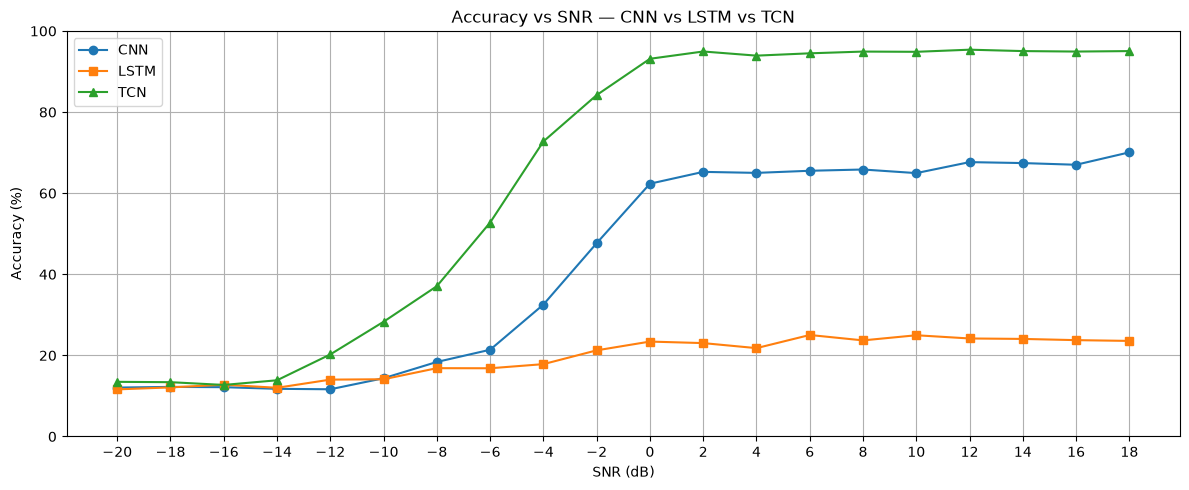

In [30]:
# Accuracy vs SNR
snr_levels = sorted(cnn_snr.keys())

plt.figure(figsize=(12, 5))
plt.plot(snr_levels, [cnn_snr[s]  * 100 for s in snr_levels], marker='o', label='CNN')
plt.plot(snr_levels, [lstm_snr[s] * 100 for s in snr_levels], marker='s', label='LSTM')
plt.plot(snr_levels, [tcn_snr[s]  * 100 for s in snr_levels], marker='^', label='TCN')
plt.xlabel('SNR (dB)')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy vs SNR — CNN vs LSTM vs TCN')
plt.legend()
plt.grid(True)
plt.xticks(snr_levels)
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig('accuracy_vs_snr.png', dpi=150)
plt.show()

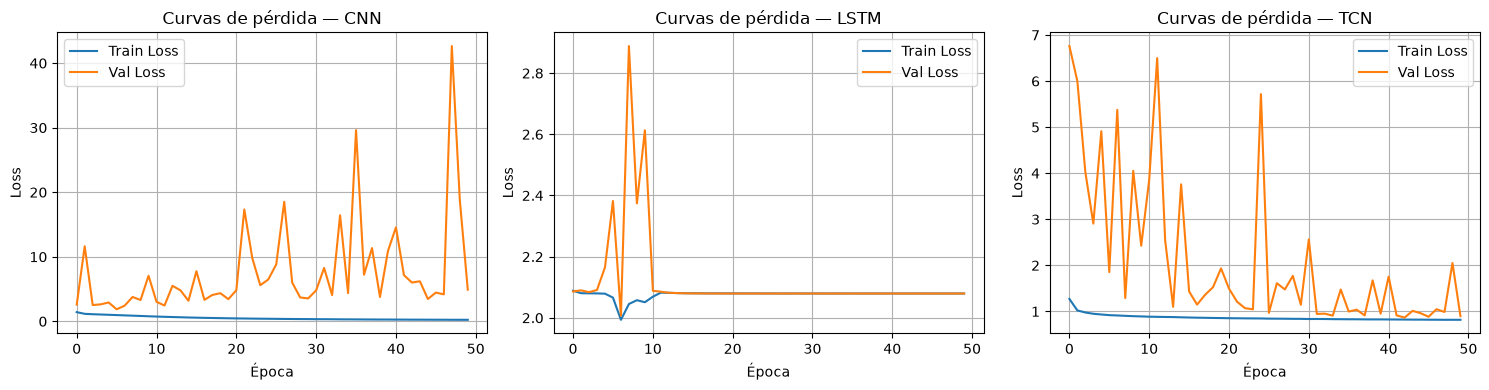

In [31]:
# Curvas de pérdida
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, history, name in zip(axes, [cnn_history, lstm_history, tcn_history], ['CNN', 'LSTM', 'TCN']):
    ax.plot(history['train_loss'], label='Train Loss')
    ax.plot(history['val_loss'],   label='Val Loss')
    ax.set_title(f'Curvas de pérdida — {name}')
    ax.set_xlabel('Época')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.savefig('curvas_perdida.png', dpi=150)
plt.show()

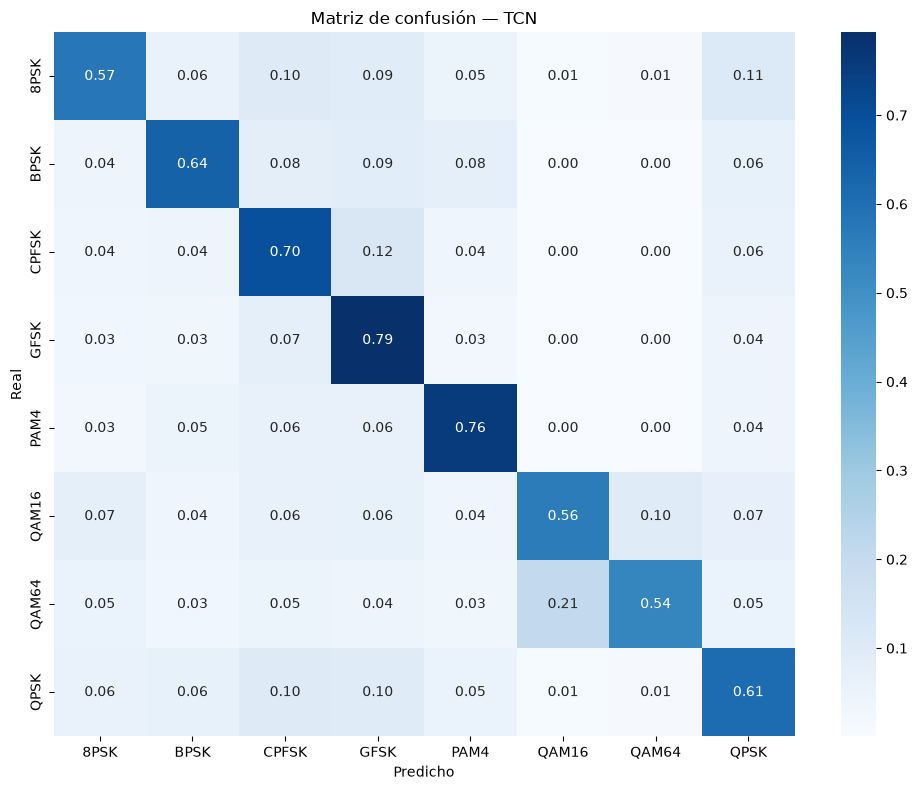

In [32]:
# Matriz de confusión — mejor modelo
def compute_confusion_matrix(model, X_test, y_test, device='cpu', batch_size=512):
    model.eval()
    loader = make_loader(X_test, y_test, batch_size=batch_size, shuffle=False)
    all_preds, all_true = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            preds = model(X_batch.to(device)).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_true.extend(y_batch.numpy())
    from sklearn.metrics import confusion_matrix
    return confusion_matrix(all_true, all_preds, normalize='true')

# Graficamos la de TCN como ejemplo
cm = compute_confusion_matrix(tcn, X_test, y_test, device=DEVICE)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='.2f',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cmap='Blues')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de confusión — TCN')
plt.tight_layout()
plt.savefig('confusion_matrix_tcn.png', dpi=150)
plt.show()

In [33]:
# Resumen de complejidad
print('=== Resumen de complejidad ===')
modelos = [('CNN', cnn), ('LSTM', lstm), ('TCN', tcn)]
for nombre, modelo in modelos:
    params = modelo.count_parameters()
    acc = overall_accuracy(modelo, X_test, y_test, DEVICE)
    print(f'{nombre:6s} | Parámetros: {params:>10,} | Accuracy: {acc:.4f}')

=== Resumen de complejidad ===
CNN    | Parámetros:  1,063,048 | Accuracy: 0.4261
LSTM   | Parámetros:    208,584 | Accuracy: 0.1932
TCN    | Parámetros:    100,552 | Accuracy: 0.6458


In [34]:
# Diagnóstico de gradientes en CNN
cnn = CNNBaseline(n_classes=8)
cnn = cnn.to(DEVICE)
optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

X_batch, y_batch = next(iter(train_loader))
X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)

optimizer.zero_grad()
logits = cnn(X_batch)
loss = criterion(logits, y_batch)
loss.backward()

print(f"Loss inicial: {loss.item():.4f}")
print(f"Gradiente primera capa conv:")
for name, param in cnn.named_parameters():
    if param.grad is not None:
        print(f"  {name}: grad_norm = {param.grad.norm().item():.6f}")
    else:
        print(f"  {name}: SIN gradiente")

Loss inicial: 2.2791
Gradiente primera capa conv:
  features.0.weight: grad_norm = 0.224712
  features.0.bias: grad_norm = 0.000032
  features.1.weight: grad_norm = 0.044912
  features.1.bias: grad_norm = 0.054890
  features.3.weight: grad_norm = 1.143486
  features.3.bias: grad_norm = 0.000000
  features.4.weight: grad_norm = 0.034762
  features.4.bias: grad_norm = 0.030127
  classifier.1.weight: grad_norm = 5.670446
  classifier.1.bias: grad_norm = 0.000000
  classifier.2.weight: grad_norm = 0.050688
  classifier.2.bias: grad_norm = 0.047905
  classifier.5.weight: grad_norm = 0.870740
  classifier.5.bias: grad_norm = 0.125954
